In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
(X, y) = load_digits(return_X_y=True, as_frame=True, n_class = 10)

Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (899, 64)
Training: (898, 64)
Test: (8

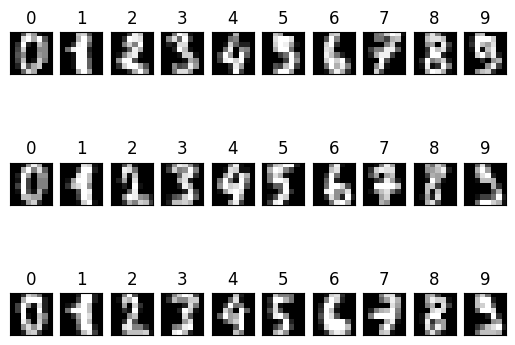

In [14]:

for i in range(30):
    plt.subplot(3, 10, i + 1)
    image = X.loc[i,:].to_numpy()
    plt.imshow(image.reshape(8, 8), cmap=plt.cm.gray)
    plt.title(y[i])
    plt.xticks(())
    plt.yticks(())
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
    print('Training:', X_train.shape)
    print('Test:', X_test.shape)
    # Scale
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_sc = scaler.transform(X_train)
    X_test_sc = scaler.transform(X_test)

In [15]:
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train_sc, y_train)
train_acc = logreg.score(X_train_sc, y_train)
test_acc = logreg.score(X_test_sc, y_test)

print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)

Training accuracy: 1.0
Test accuracy: 0.9655172413793104


/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


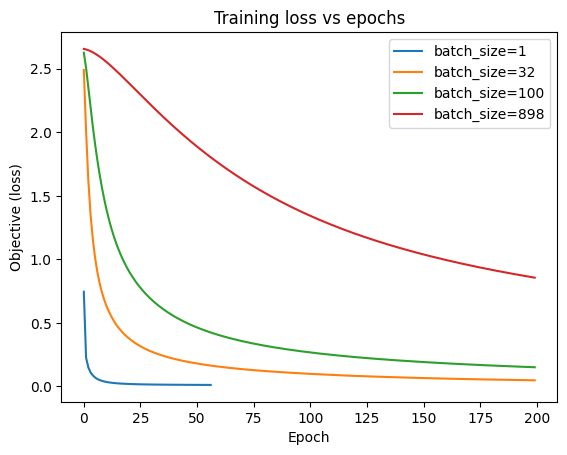

In [16]:
batch_sizes = [1, 32, 100, 898]

plt.figure()

for b in batch_sizes:
    
    mlp = MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='tanh',
        solver='sgd',
        batch_size=b,
        max_iter=200,
        random_state=12
    )
    
    mlp.fit(X_train_sc, y_train)
    
    plt.plot(mlp.loss_curve_, label=f"batch_size={b}")

plt.xlabel("Epoch")
plt.ylabel("Objective (loss)")
plt.title("Training loss vs epochs")
plt.legend()
plt.show()

In [8]:
neurons = [5, 10, 20, 100, 200, 300]

train_acc = []
test_acc = []

for m in neurons:
    
    mlp = MLPClassifier(
        hidden_layer_sizes=(m,),
        activation='tanh',
        solver='sgd',
        max_iter=300,
        random_state=12
    )
    
    mlp.fit(X_train_sc, y_train)
    
    train_acc.append(mlp.score(X_train_sc, y_train))
    test_acc.append(mlp.score(X_test_sc, y_test))

/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum itera

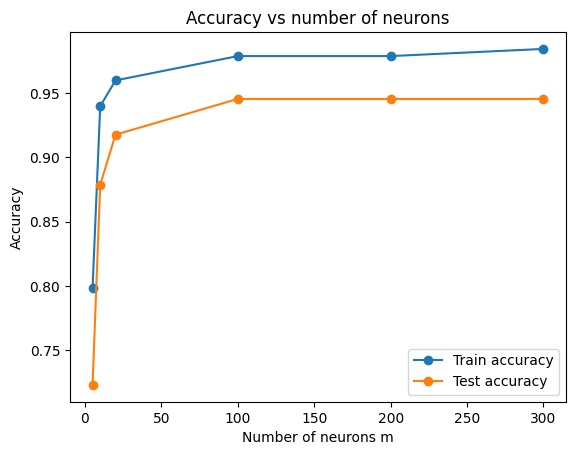

In [9]:
plt.figure()

plt.plot(neurons, train_acc, marker='o', label="Train accuracy")
plt.plot(neurons, test_acc, marker='o', label="Test accuracy")

plt.xlabel("Number of neurons m")
plt.ylabel("Accuracy")
plt.title("Accuracy vs number of neurons")
plt.legend()

plt.show()

In [10]:
deep_mlp = MLPClassifier(
    hidden_layer_sizes=(100,100,10),
    activation='tanh',
    solver='sgd',
    max_iter=300,
    random_state=12
)

deep_mlp.fit(X_train_sc, y_train)

train_acc = deep_mlp.score(X_train_sc, y_train)
test_acc = deep_mlp.score(X_test_sc, y_test)

print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)

Training accuracy: 0.9810690423162584
Test accuracy: 0.92880978865406


/Users/ekaterinaleontieva/opt/anaconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,100),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=12
)

mlp.fit(X_train_sc, y_train)

print("Test accuracy:", mlp.score(X_test_sc, y_test))

Test accuracy: 0.9733036707452726
